Paquetes necesarios

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

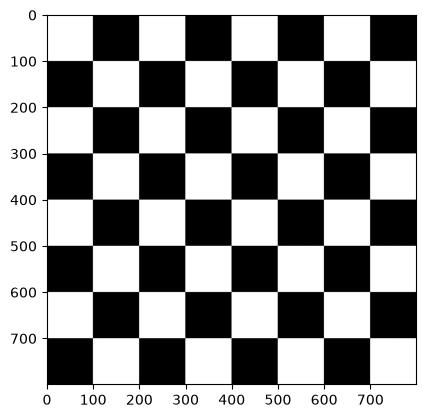

In [3]:
width = 800
height = 800
block_size = width // 8

board = np.zeros((height,width,1), dtype = np.uint8)

for i in range(0, 8):
    for j in range(0, 8):
        if (i + j) % 2 == 0:
            board[i*block_size:i*block_size + block_size, j*block_size: j*block_size + block_size] = 255


plt.imshow(board, cmap='gray',vmin=0, vmax=255)
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

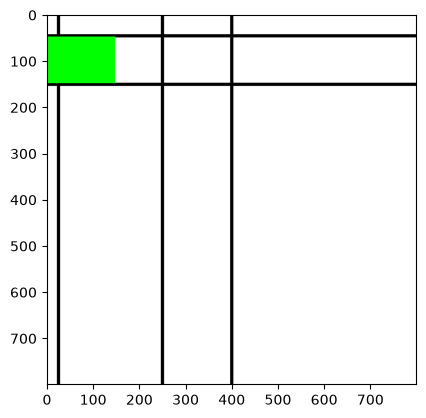

True

In [4]:
width = 800
height = 800

mondrian = np.zeros((height,width,3), dtype = np.uint8)
mondrian[:,:,:] = 255

cv2.line(mondrian, (int(width/2), 0), (int(width/2), height), (0, 0, 0), 5)
cv2.line(mondrian, (25, 0), (25, height), (0, 0, 0), 5)
cv2.line(mondrian, (250, 0), (250, height), (0, 0, 0), 5)

cv2.line(mondrian, (0, 45), (width, 45), (0, 0, 0), 5)
cv2.line(mondrian, (0, 150), (width, 150), (0, 0, 0), 5)

#Rectángulo con grosor 2
cv2.rectangle(mondrian,(0,47),(147, 147),(0,255,0), -1)
#Rectángulo relleno
#cv2.rectangle(color_img,(20,20),(60,40),(0,255,0),-1)
#Círculo de radio 15 relleno
#cv2.circle(color_img,(width-60,30), 15, (0,0,255), -1)
#Visualiza sin especificar el mapa de color gris
plt.imshow(mondrian) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('mondrian.jpg', mondrian)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [7]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
#w=int(w/2)
#h=int(h/2)
#vid.set(cv2.CAP_PROP_FRAME_WIDTH, w)
#vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

fn = 121
while True:

    ret, frame = vid.read()
    if not ret:
        continue
    fn += 1

    if fn > 30:
        fn = 0

        max_pixel = 0
        max_pixel_pos = (0, 0)
        min_pixel = 255
        min_pixel_pos = (0, 0)
        for i in range(0, h):
            for j in range(0, w):
                value = int(frame[i, j, 0]) + int(frame[i, j, 1]) + int(frame[i, j, 2])
                if value > max_pixel:
                    max_pixel = value
                    max_pixel_pos = (j, i)
                if value < min_pixel:
                    min_pixel = value
                    min_pixel_pos = (j, i)

    print(f"Max: {max_pixel}, {max_pixel_pos}")
    print(f"Min: {min_pixel}, {min_pixel_pos}")
    cv2.circle(frame, min_pixel_pos, 10, (255,0,0), 1)
    cv2.circle(frame, max_pixel_pos, 10, (0,0,255), 1)
    cv2.imshow('Cam', frame)

        # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break

# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()


Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)
Max: 765, (592, 234)
Min: 19, (92, 428)


In [ ]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tr = collage[0:h,w:w+w]
bl = collage[h:h+h,0:w]
br = collage[h:h+h,w:w+w]
fn = 0
while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        tl[:,:,0] = b
        tl[:,:,1] = g
        tl[:,:,2] = r

        tr[:,:,0] = 255 - r
        tr[:,:,1] = g
        tr[:,:,2] = b
        
        bl[:,:,0] = r
        bl[:,:,1] = 255 - b
        bl[:,:,2] = g

        br[:,:,0] = b
        br[:,:,1] = g
        br[:,:,2] = 255 - r
    
        # Muestra composición
        cv2.imshow('Cam', collage)
    fn += 1
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.